In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()


In [2]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
all_spatial= adata_mer.obsm['spatial']
all_spatial = processing.get_hemi(all_spatial, mesh_LC)    
all_spatial*= 25

In [3]:
# 1a.  Gene expression matrix (dense is fine for 2 600 × 314)
X = adata_mer.X.A if hasattr(adata_mer.X, "A") else adata_mer.X  # handle sparse
# X_niche = adata_niche.obsm['nicheformer']

coords = all_spatial.copy()

In [4]:
X.shape

(2651, 314)

In [6]:
X.max(),X.min()

(array(0.24816138, dtype=float32), array(8.3821163e-07, dtype=float32))

# MLP

In [7]:
# 1) Assume you already have these NumPy arrays from your splits:
#    X_train, X_val, X_test  shape = (n_samples, n_features)
#    y_train, y_val, y_test  shape = (n_samples, 3)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, coords, 
    test_size=0.40,
    random_state=42
)

# 2) second split: val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,y_tmp, 
    test_size=0.50,
    random_state=42
)

# 2) Hyperparameters
input_dim  = X_train.shape[1]   # e.g. 314 genes
hidden_dim = 128
batch_size = 64
num_epochs = 100
lr_grid    = [1e-3, 1e-2, 1e-1, 5e-1, 1e-0]




NameError: name 'StandardScaler' is not defined

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


scaler_y = StandardScaler().fit(y_train)
y_train = scaler_y.transform(y_train)
y_val   = scaler_y.transform(y_val)
y_test  = scaler_y.transform(y_test)

In [26]:
np.mean(y_test, 0)

array([ 0.07520781, -0.03784695, -0.01324714])

In [27]:
np.var(y_test, 0)

array([0.91215539, 1.0214279 , 0.92734002])

In [28]:

# 3) DataLoaders
def make_loader(X, y, shuffle=True):
    tx = torch.from_numpy(X.astype(np.float32))
    ty = torch.from_numpy(y.astype(np.float32))
    ds = TensorDataset(tx, ty)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)


In [29]:

# 4) Two-layer MLP definition
class TwoLayerMLP(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)



In [57]:
# 5) Grid search over learning rates
val_mse_per_lr = {}
for lr in lr_grid:
    model     = TwoLayerMLP(input_dim, hidden_dim)
#     nn.Dropout(0.2)  
#     optimizer = optim.Adam(model.parameters(), lr=best_lr, weight_decay=1e-4)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # training loop    
    train_loss = []
    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss  = criterion(preds, yb)
            loss.backward()
            print(loss,'evaluate')
            train_loss.append(loss)
            optimizer.step()
        
        model.eval()
        

    # validation
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            p = model(xb)
            all_preds.append(p.numpy())
            all_targets.append(yb.numpy())
    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    mse_val = mean_squared_error(all_targets, all_preds)
    r2_val  = r2_score(all_targets, all_preds, multioutput="raw_values")
    val_mse_per_lr[lr] = mse_val
    print(f"LR = {lr:.0e} → val MSE = {mse_val:.4f}, val r2 = {r2_val}")

# pick best learning rate
best_lr = min(val_mse_per_lr, key=val_mse_per_lr.get)
print(f"\nBest LR = {best_lr:.0e}, val MSE = {val_mse_per_lr[best_lr]:.4f}")


LR = 1e-03 → val MSE = 172867.9844, val r2 = [-0.09587634  0.00934595 -0.04576528]
LR = 1e-02 → val MSE = 166836.2656, val r2 = [-0.04702592  0.05605376 -0.08908391]
LR = 1e-01 → val MSE = 56973.2773, val r2 = [0.6005074  0.7158567  0.41976458]
LR = 5e-01 → val MSE = 87993.0391, val r2 = [-1.450125   0.7119496  0.2292158]
LR = 1e+00 → val MSE = 56993.9180, val r2 = [0.4992711  0.72590625 0.4153096 ]

Best LR = 1e-01, val MSE = 56973.2773


In [58]:
num_epochs_final = 1000
# 6) Retrain on train+val with best LR
X_combined = np.vstack([X_train, X_val])
y_combined = np.vstack([y_train, y_val])
comb_loader = make_loader(X_combined, y_combined, shuffle=True)

model_best = TwoLayerMLP(input_dim, hidden_dim)
optimizer  = optim.Adam(model_best.parameters(), lr=best_lr)
criterion  = nn.MSELoss()
losses = []
for epoch in range(num_epochs_final):
    model_best.train()
    for xb, yb in comb_loader:
        optimizer.zero_grad()
        loss = criterion(model_best(xb), yb)
        loss.backward()
        optimizer.step()
    losses.append(loss)


/scratch/fast/1045878/ipykernel_2864149/3582001079.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot([np.log1p(m.detach())for m in losses], '-o')


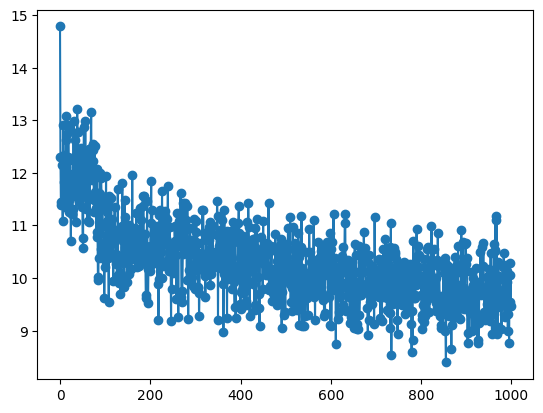

In [59]:
plt.plot([np.log1p(m.detach())for m in losses], '-o')


In [67]:


# 7) Final test evaluation
model_best.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        p = model_best(xb)
        all_preds.append(p.numpy())
        all_targets.append(yb.numpy())
all_preds   = np.vstack(all_preds)
all_targets = np.vstack(all_targets)
test_mse = mean_squared_error(all_targets, all_preds)
test_r2  = r2_score(all_targets, all_preds, multioutput='variance_weighted')
print(f"\nTEST SET MSE = {test_mse:.4f}")
print(f"\nTEST SET R² = {test_r2}")



TEST SET MSE = 56623.5000

TEST SET R² = 0.7243707776069641


In [65]:
r2_score??

In [61]:
r2_score(all_targets, all_preds)

0.5941142439842224

In [63]:
np.sum((all_targets-np.mean(all_targets,0))**2)

np.float32(327255680.0)

In [64]:
np.sum((all_targets-np.mean(all_preds,0))**2)/np.prod(all_targets.shape)

np.float64(210718.75455116134)